In [1]:
#shap!!
import shap

import pandas as pd
import numpy as np
import tensorflow as tf
import tensorflow.keras.backend as K
import matplotlib.pyplot as plt
plt.style.use('ggplot')

from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D

/Users/felipealencar/miniconda3/envs/tensorflow2.12/lib/python3.8/site-packages/shap/utils/_clustering.py:35: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def _pt_shuffle_rec(i, indexes, index_mask, partition_tree, M, pos):
/Users/felipealencar/miniconda3/envs/tensorflow2.12/lib/python3.8/site-packages/shap/utils/_clustering.py:54: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-ji

In [22]:
import glob
import numpy as np
import tifffile as tiff
import pandas as pd
from skimage.transform import resize
import re
import skimage.transform as skt
import os
from dotenv import load_dotenv

# Load the .env file
load_dotenv()

# Check if the .env file was loaded
print(os.getenv('DATASET_DIR'))

# Specify the directory path where the .tif images are located
directory_path_1 = r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Repos\plant-disease-prediction\dataset\LARGO1\08-30\*.tif'
directory_path_2 = r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Repos\plant-disease-prediction\dataset\LARGO2\08-30\*.tif'
directory_path_3 = r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Repos\plant-disease-prediction\dataset\LARGO1\08-30-temporal-synthetic\*.tiff'

# Concat a string with directory path and file extension
directory_path_1 = directory_path + system_slash + 'LARGO1' + system_slash + '08-30' + system_slash + '*.tif'
directory_path_2 = directory_path + system_slash + 'LARGO2' + system_slash + '08-30' + system_slash + '*.tif'

# Get the file paths of all .tif images in the directory
# Convert the directory path to a raw string
# Retrieve the file paths of all .tif images in the directory
image_paths = glob.glob(directory_path_1) + glob.glob(directory_path_2) + glob.glob(directory_path_3)

# Extract the labels from the filenames
labels = [path.split('_')[-1].split('.')[0] for path in image_paths]

# Load and resize the .tif images
flattened_images = []
label_list = []
image_data = []

# List the image paths and labels
print('Image paths:', image_paths)


Image paths: ['C:\\Users\\flopes1\\OneDrive - Saint Louis University\\Desktop\\Repos\\plant-disease-prediction\\dataset\\LARGO1\\08-30\\imagem_segmentada_100_0830_AVARAGE.tif', 'C:\\Users\\flopes1\\OneDrive - Saint Louis University\\Desktop\\Repos\\plant-disease-prediction\\dataset\\LARGO1\\08-30\\imagem_segmentada_101_0830_None.tif', 'C:\\Users\\flopes1\\OneDrive - Saint Louis University\\Desktop\\Repos\\plant-disease-prediction\\dataset\\LARGO1\\08-30\\imagem_segmentada_102_0830_AVARAGE.tif', 'C:\\Users\\flopes1\\OneDrive - Saint Louis University\\Desktop\\Repos\\plant-disease-prediction\\dataset\\LARGO1\\08-30\\imagem_segmentada_103_0830_AVARAGE.tif', 'C:\\Users\\flopes1\\OneDrive - Saint Louis University\\Desktop\\Repos\\plant-disease-prediction\\dataset\\LARGO1\\08-30\\imagem_segmentada_104_0830_None.tif', 'C:\\Users\\flopes1\\OneDrive - Saint Louis University\\Desktop\\Repos\\plant-disease-prediction\\dataset\\LARGO1\\08-30\\imagem_segmentada_105_0830_None.tif', 'C:\\Users\\flope

In [23]:

for path, label in zip(image_paths, labels):
    match = re.search(r'(\w+)\s*(?:\(\d+\))?', label)
    if match:
        extracted_label = match.group(1)
        if extracted_label != 'None':  # Ignore images with the label 'None'
            image = tiff.imread(path)
            if 'temporal-synthetic' in path:
                flattened_image = image.flatten()
                # Check flattened image size
                # print('Synthetic flattened size:', flattened_image.size)
            else:
                resized_image = skt.resize(image, (128, 128), mode='reflect')  # Resize to 128x128
                flattened_image = resized_image.flatten()  # Flatten the image
                # Check flattened image size
                # print('Real flattened size:', flattened_image.size)
            flattened_images.append(flattened_image)
            label_list.append(label)
    else:
        extracted_label = label
        if extracted_label != 'None':  # Ignore images with the label 'None'
            image = tiff.imread(path)
            # Verify if path is from the synthetic dataset
            if 'temporal-synthetic' in path:
                flattened_image = image.flatten()
            else:
                resized_image = skt.resize(image, (128, 128), mode='reflect')  # Resize to 128x128
                flattened_image = resized_image.flatten()  # Flatten the image
            flattened_images.append(flattened_image)
            label_list.append(label)

# Get the maximum size along dimension 1
max_size = max(flattened_image.size for flattened_image in flattened_images)

# Reshape the flattened images to have a consistent size along dimension 1
reshaped_images = [np.pad(flattened_image, (0, max_size - flattened_image.size), mode='constant') for flattened_image in flattened_images]

# Stack the reshaped images
combined_matrix = np.vstack(reshaped_images)

# Check the shape of the combined matrix
print('Combined matrix shape:', combined_matrix.shape)
# Check the size of the combined matrix
print('Combined matrix size:', combined_matrix.size)

# Create column names for the DataFrame
column_names = [f'Pixel_{i}' for i in range(combined_matrix.shape[1])]

# Convert the combined matrix to a DataFrame and add labels
df = pd.DataFrame(combined_matrix, columns=column_names)
df['Label'] = label_list
print(df.head())

Combined matrix shape: (612, 81920)
Combined matrix size: 50135040
   Pixel_0  Pixel_1  Pixel_2  Pixel_3  Pixel_4  Pixel_5  Pixel_6  Pixel_7  \
0      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
1      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
2      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
3      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
4      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   

   Pixel_8  Pixel_9  ...  Pixel_81911  Pixel_81912  Pixel_81913  Pixel_81914  \
0      0.0      0.0  ...          0.0          0.0          0.0          0.0   
1      0.0      0.0  ...          0.0          0.0          0.0          0.0   
2      0.0      0.0  ...          0.0          0.0          0.0          0.0   
3      0.0      0.0  ...          0.0          0.0          0.0          0.0   
4      0.0      0.0  ...          0.0          0.0          0.0       

In [22]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# Load the preprocessed dataset
# df = pd.read_csv('output-images.csv')  # Replace with the path to your preprocessed dataset CSV file
df = pd.read_csv('output-temporal-synthetic-images.csv')  # Replace with the path to your preprocessed dataset CSV file
print(df.shape)

# Display the possible labels
print(df['Label'].value_counts())

# Categorize AVARAGE as UNHEALTHY
df['Label'] = df['Label'].replace('AVERAGE', 'UNHEALTHY')

# Remove the '0830'and 'ALL' samples/labels
df = df[df['Label'] != '0830']
df = df[df['Label'] != 'ALL']

# Split the dataset into features (X) and labels (y)
X = df.drop('Label', axis=1).values
y = df['Label'].values


# Display the possible labels
print(df['Label'].value_counts())


(612, 81921)
AVARAGE      430
HEALTHY      126
UNHEALTHY     56
Name: Label, dtype: int64
AVARAGE      430
HEALTHY      126
UNHEALTHY     56
Name: Label, dtype: int64


In [23]:
# Categorize AVARAGE as UNHEALTHY
df['Label'] = df['Label'].replace('AVARAGE', 'UNHEALTHY')

# Remove the '0830'and 'ALL' samples/labels
df = df[df['Label'] != '0830']
df = df[df['Label'] != 'ALL']

# Split the dataset into features (X) and labels (y)
X = df.drop('Label', axis=1).values
y = df['Label'].values

# Perform label encoding for categorical labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# Convert the integer labels to one-hot encoded vectors
num_classes = len(label_encoder.classes_)
y = to_categorical(y, num_classes=num_classes)

# Print the label counts
print(df['Label'].value_counts())


Label
UNHEALTHY    486
HEALTHY      126
Name: Label, dtype: int64


In [21]:

# Split the data into train, test, and validation sets:
# 70% train, 20% test, and 10% validation
# Stratify the split to ensure that the class distribution is consistent
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=0)

# Split the test set into test and validation sets
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.33, stratify=y_test, random_state=0)

# Save the validation set and its labels to a .csv file
#val_df = pd.DataFrame(X_val)
#val_df['Label'] = label_encoder.inverse_transform(np.argmax(y_val, axis=1))
#val_df.to_csv('image-based-validation_set.csv', index=False)

# Load the validation set and its labels from a .csv file
val_df = pd.read_csv('image-based-validation_set.csv')
X_val = val_df.drop('Label', axis=1).values
y_val = val_df['Label'].values
y_val = label_encoder.transform(y_val)
y_val = to_categorical(y_val, num_classes=num_classes)

# Reshape the input data to match the CNN input shape (assuming images are grayscale)
input_shape = (128, 128, 5)  # Adjust the input shape based on your image size and channels
X_train = X_train.reshape(-1, *input_shape)
X_test = X_test.reshape(-1, *input_shape)

# Normalize the input data to a range of [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Create the CNN model
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, batch_size=32, epochs=10, validation_data=(X_test, y_test))

# # Evaluate the model on the test set
# loss, accuracy = model.evaluate(X_test, y_test)
# print(f'Test loss: {loss:.4f}')
# print(f'Test accuracy: {accuracy:.4f}')

# # Generate predictions on the test set
# y_pred = model.predict(X_test)
# y_pred_classes = np.argmax(y_pred, axis=1)
# y_test_classes = np.argmax(y_test, axis=1)

# # Decode the one-hot encoded predictions and true labels
# y_pred_labels = label_encoder.inverse_transform(y_pred_classes)
# y_test_labels = label_encoder.inverse_transform(y_test_classes)

# # Print classification report
# print(classification_report(y_test_labels, y_pred_labels))

Epoch 1/10
13/13 [==============================] - 4s 226ms/step - loss: 0.5359 - accuracy: 0.8140 - val_loss: 0.4982 - val_accuracy: 0.8235
Epoch 2/10
13/13 [==============================] - 3s 213ms/step - loss: 0.4872 - accuracy: 0.8213 - val_loss: 0.4689 - val_accuracy: 0.8235
Epoch 3/10
13/13 [==============================] - 3s 213ms/step - loss: 0.4799 - accuracy: 0.8213 - val_loss: 0.4720 - val_accuracy: 0.8235
Epoch 4/10
13/13 [==============================] - 3s 212ms/step - loss: 0.4996 - accuracy: 0.8213 - val_loss: 0.4809 - val_accuracy: 0.8235
Epoch 5/10
13/13 [==============================] - 3s 215ms/step - loss: 0.4915 - accuracy: 0.8213 - val_loss: 0.4628 - val_accuracy: 0.8235
Epoch 6/10
13/13 [==============================] - 3s 213ms/step - loss: 0.5070 - accuracy: 0.8213 - val_loss: 0.4666 - val_accuracy: 0.8235
Epoch 7/10
13/13 [==============================] - 3s 213ms/step - loss: 0.5145 - accuracy: 0.8213 - val_loss: 0.5017 - val_accuracy: 0.8235
Epoch 

In [24]:

# Split the data into train, test, and validation sets:
# 70% train, 20% test, and 10% validation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=0)

# Split the test set into test and validation sets
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.33, stratify=y_test, random_state=0)

# Save the validation set and its labels to a .csv file
#val_df = pd.DataFrame(X_val)
#val_df['Label'] = label_encoder.inverse_transform(np.argmax(y_val, axis=1))
#val_df.to_csv('image-based-validation_set.csv', index=False)

# Reshape the input data to match the CNN input shape (assuming images are grayscale)
input_shape = (128, 128, 5)  # Adjust the input shape based on your image size and channels
X_train = X_train.reshape(-1, *input_shape)
X_test = X_test.reshape(-1, *input_shape)

# Normalize the input data to a range of [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Create the CNN model
model_synthetic = Sequential()
model_synthetic.add(Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
model_synthetic.add(MaxPooling2D((2, 2)))
model_synthetic.add(Conv2D(64, (3, 3), activation='relu'))
model_synthetic.add(MaxPooling2D((2, 2)))
model_synthetic.add(Flatten())
model_synthetic.add(Dense(64, activation='relu'))
model_synthetic.add(Dropout(0.5))
model_synthetic.add(Dense(num_classes, activation='softmax'))

# Compile the model
model_synthetic.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
model_synthetic.fit(X_train, y_train, batch_size=32, epochs=10, validation_data=(X_test, y_test))

Epoch 1/10
14/14 [==============================] - 4s 215ms/step - loss: 0.5697 - accuracy: 0.7523 - val_loss: 0.5096 - val_accuracy: 0.7967
Epoch 2/10
14/14 [==============================] - 3s 204ms/step - loss: 0.5223 - accuracy: 0.7944 - val_loss: 0.5072 - val_accuracy: 0.7967
Epoch 3/10
14/14 [==============================] - 3s 208ms/step - loss: 0.5334 - accuracy: 0.7944 - val_loss: 0.5151 - val_accuracy: 0.7967
Epoch 4/10
14/14 [==============================] - 3s 204ms/step - loss: 0.5322 - accuracy: 0.7944 - val_loss: 0.5484 - val_accuracy: 0.7967
Epoch 5/10
14/14 [==============================] - 3s 206ms/step - loss: 0.5254 - accuracy: 0.7944 - val_loss: 0.5034 - val_accuracy: 0.7967
Epoch 6/10
14/14 [==============================] - 3s 203ms/step - loss: 0.5328 - accuracy: 0.7944 - val_loss: 0.5094 - val_accuracy: 0.7967
Epoch 7/10
14/14 [==============================] - 3s 204ms/step - loss: 0.5420 - accuracy: 0.7944 - val_loss: 0.5079 - val_accuracy: 0.7967
Epoch 

In [79]:
# Save the model_synthetic to a .h5 file
model_synthetic.save('image-based-cnn-model_synthetic.h5')

# Save the model to a .h5 file
model.save('image-based-cnn-model.h5')

In [4]:
# Load the validation set and its labels from a .csv file
val_df = pd.read_csv('image-based-validation_set.csv')
print(val_df['Label'].value_counts())
X_val = val_df.drop('Label', axis=1).values
y_val = val_df['Label'].values
y_val = label_encoder.transform(y_val)
y_val = to_categorical(y_val, num_classes=num_classes)

print(y_val)

UNHEALTHY    45
HEALTHY      14
Name: Label, dtype: int64
[[0. 1.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [1. 0.]]


In [25]:
import numpy as np
import shap

# Assuming you have trained your model and defined X_val, y_val, and input_shape earlier in your code

# Reshape the validation data to match the CNN input shape
X_val_reshaped = X_val.reshape(-1, *input_shape)

# Normalize the input data to a range of [0, 1]
X_val_normalized = X_val_reshaped.astype('float32') / 255.0

# Calculate SHAP values for the correctly classified images in the validation set
explainer_real = shap.DeepExplainer(model, X_train)
explainer_synthetic = shap.DeepExplainer(model_synthetic, X_train)

shap_values_real = explainer_real.shap_values(X_val_normalized)
shap_values_synthetic = explainer_synthetic.shap_values(X_val_normalized)

# Get the predicted classes for the validation set
y_pred_real = model.predict(X_val_normalized)
print(y_pred_real)
y_pred_synthetic = model_synthetic.predict(X_val_normalized)
print(y_pred_synthetic)
y_pred_real_classes = np.argmax(y_pred_real, axis=1)
y_pred_synthetic_classes = np.argmax(y_pred_synthetic, axis=1)
y_true_classes = np.argmax(y_val, axis=1)

# Find the indices of correctly classified images
correct_indices_real = np.where(y_pred_real_classes == y_true_classes)[0]
correct_indices_synthetic = np.where(y_pred_synthetic_classes == y_true_classes)[0]


C:\Users\flopes1\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\shap\explainers\_deep\deep_tf.py:99: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn("Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.")
C:\Users\flopes1\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\keras\backend.py:451: UserWarning: `tf.keras.backend.set_learning_phase` is deprecated and will be removed after 2020-10-11. To update it, simply pass a True/False value to the `training` argument of the `__call__` method of your layer or model.
  warnings.warn(


2/2 [==============================] - 0s 40ms/step
[[0.20264016 0.7973598 ]
 [0.20352916 0.7964709 ]
 [0.18157719 0.8184228 ]
 [0.18176326 0.8182367 ]
 [0.20209864 0.79790133]
 [0.20185912 0.7981408 ]
 [0.18181406 0.8181859 ]
 [0.20255901 0.797441  ]
 [0.1815214  0.81847864]
 [0.2023601  0.7976399 ]
 [0.20178318 0.7982169 ]
 [0.20153351 0.79846656]
 [0.20305714 0.7969429 ]
 [0.2035646  0.7964354 ]
 [0.20250276 0.7974973 ]
 [0.2036074  0.7963926 ]
 [0.20271102 0.79728895]
 [0.20213301 0.79786694]
 [0.2026225  0.79737747]
 [0.18179832 0.8182017 ]
 [0.1818902  0.81810975]
 [0.20219986 0.7978001 ]
 [0.20242728 0.7975727 ]
 [0.20160285 0.7983972 ]
 [0.18413125 0.8158688 ]
 [0.1846884  0.8153116 ]
 [0.20314002 0.79686   ]
 [0.1816211  0.8183789 ]
 [0.18183336 0.8181667 ]
 [0.18179758 0.81820244]
 [0.20206042 0.7979396 ]
 [0.20247711 0.7975229 ]
 [0.20245843 0.7975416 ]
 [0.20240036 0.7975997 ]
 [0.18202053 0.8179794 ]
 [0.18171935 0.81828064]
 [0.20226087 0.7977391 ]
 [0.18352331 0.8164767 

In [26]:
correct_indices = np.intersect1d(correct_indices_real, correct_indices_synthetic)

In [27]:
print(y_val[0][0])
print(correct_indices_real)
print(correct_indices_synthetic)
#correct_indices = np.where(y_pred_real_classes == y_true_classes and y_pred_synthetic_classes == y_true_classes)[0]
print(correct_indices)
print(y_true_classes[correct_indices])
print(y_true_classes)

1.0
[ 2  3  5  6  7  8  9 10 11 12 15 16 17 18 19 20 21 26 27 28 29 30 32 33
 34 35 36 39 40 41 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60]
[ 2  3  5  6  7  8  9 10 11 12 15 16 17 18 19 20 21 26 27 28 29 30 32 33
 34 35 36 39 40 41 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60]
[ 2  3  5  6  7  8  9 10 11 12 15 16 17 18 19 20 21 26 27 28 29 30 32 33
 34 35 36 39 40 41 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60]
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1]
[0 0 1 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 0 0 0 0 1 1 1 1 1 0 1 1 1 1 1
 0 0 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


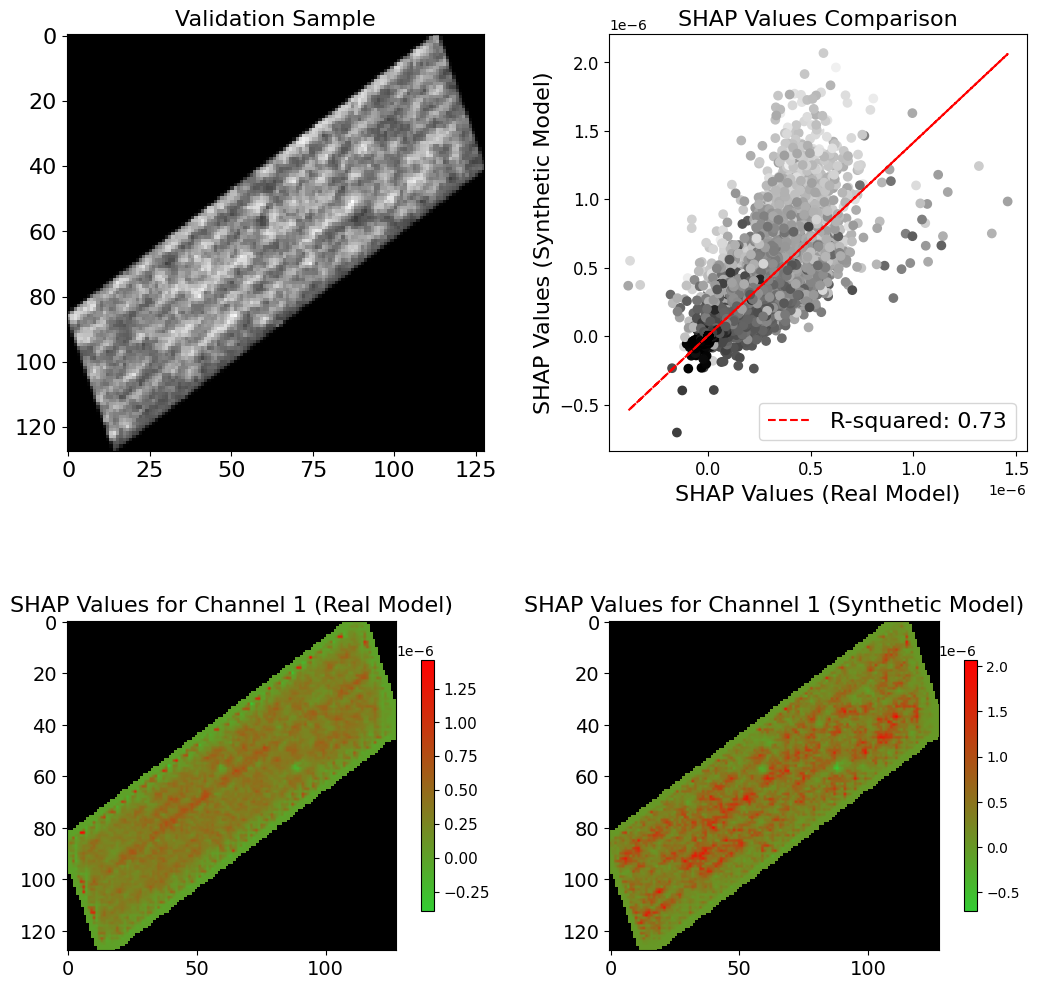

In [75]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress
from matplotlib.colors import LinearSegmentedColormap

# Define the custom colormap from green to red
colors = [(0.2, 0.8, 0.2), (1, 0, 0)]  # Green to red
cmap_custom = LinearSegmentedColormap.from_list('custom_cmap', colors)

# Choose the channel you want to visualize (assuming channel 1)
channel_index = 3  # Assuming channels are indexed from 0

# Choose the index of the image you want to visualize
image_index = correct_indices[10]  # Visualizing the first correctly classified image

# Choose the SHAP values for the selected channel and image
shap_values_real_channel = shap_values_real[image_index, :, :, channel_index, 0]
shap_values_synthetic_channel = shap_values_synthetic[image_index, :, :, channel_index, 0]

# Create a mask based on the original image where black pixels are set to 0
mask = np.where(X_val_normalized[image_index, :, :, channel_index] == 0, 0, 1)

# Apply the mask to the SHAP values for the real model
masked_shap_values_real = shap_values_real_channel * mask
masked_shap_values_real = masked_shap_values_real
# Apply the mask to the SHAP values for the synthetic model
masked_shap_values_synthetic = shap_values_synthetic_channel * mask
masked_shap_values_synthetic = masked_shap_values_synthetic

# Get pixel intensities of the validation sample
pixel_intensities = X_val_normalized[image_index, :, :, channel_index]

# Create a grid of plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

aspect_ratio = masked_shap_values_real.shape[1] / masked_shap_values_real.shape[0]

plt.subplots_adjust(left=0.3, right=0.9, bottom=0.1, top=0.9, wspace=0.3, hspace=0.3)

# Plot the validation image
im0 = axes[0, 0].imshow(X_val_normalized[image_index, :, :, channel_index], cmap='gray')
axes[0, 0].set_title('Validation Sample', fontsize=16)  # Increase fontsize
axes[0, 0].tick_params(axis='both', which='major', labelsize=16)  # Increase tick fontsize

# Plot the SHAP values for the real model
im1 = axes[1, 0].imshow(masked_shap_values_real, cmap=cmap_custom, alpha=1.0)
axes[1, 0].set_title('SHAP Values for Channel 1 (Real Model)', fontsize=16)  # Increase fontsize
axes[1, 0].tick_params(axis='both', which='major', labelsize=14)  # Increase tick fontsize

# Overlay the black areas of the original image for the real model
black_areas = np.ma.masked_where(mask == 1, mask)
axes[1, 0].imshow(black_areas, cmap='gray', alpha=1.0)

# Plot the SHAP values for the synthetic model
im2 = axes[1, 1].imshow(masked_shap_values_synthetic, cmap=cmap_custom, alpha=1.0)
axes[1, 1].set_title('SHAP Values for Channel 1 (Synthetic Model)', fontsize=16)  # Increase fontsize
axes[1, 1].tick_params(axis='both', which='major', labelsize=14)  # Increase tick fontsize

# Overlay the black areas of the original image for the synthetic model
axes[1, 1].imshow(black_areas, cmap='gray', alpha=1.0)

# Add the scatter plot comparing SHAP values from real and synthetic models
scatter = axes[0, 1].scatter(masked_shap_values_real.flatten(), masked_shap_values_synthetic.flatten(), c=pixel_intensities.flatten(), cmap='gray')
axes[0, 1].set_xlabel('SHAP Values (Real Model)', fontsize=16)  # Increase fontsize
axes[0, 1].set_ylabel('SHAP Values (Synthetic Model)', fontsize=16)  # Increase fontsize
axes[0, 1].set_title('SHAP Values Comparison', fontsize=16)  # Increase fontsize
axes[0, 1].tick_params(axis='both', which='major', labelsize=12)  # Increase tick fontsize

# Calculate the R-squared value and plot the line
slope, intercept, r_value, p_value, std_err = linregress(masked_shap_values_real.flatten(), masked_shap_values_synthetic.flatten())
axes[0, 1].plot(masked_shap_values_real.flatten(), slope * masked_shap_values_real.flatten() + intercept, color='red', linestyle='--', label=f'R-squared: {r_value**2:.2f}')
axes[0, 1].legend(fontsize=16)  # Increase legend fontsize

# Add a colorbar for SHAP plots
cbar1 = fig.colorbar(im1, ax=axes[1, 0], shrink=0.6, pad=0.06)
cbar1.ax.tick_params(labelsize=11)  # Increase colorbar tick fontsize
cbar1.ax.yaxis.set_label_position('right')  # Adjust the position of the notation
cbar2 = fig.colorbar(im2, ax=axes[1, 1], shrink=0.6, pad=0.06)

plt.show()



In [77]:
# Save plot to pdf file
fig.savefig('output-shap.pdf', bbox_inches='tight')

In [ ]:
# Display images with SHAP values for correctly classified examples
def display_correct_with_shap(correct_indices, X_val, y_pred_classes, y_true_classes, shap_values):
    """ This function shows images with SHAP values for correctly classified examples"""
    n = 0
    nrows = 2
    ncols = 4
    fig, ax = plt.subplots(nrows, ncols, sharex=True, sharey=True, figsize=(20, 8))
    for row in range(nrows):
        for col in range(ncols):
            index = correct_indices[n]
            image = X_val[index].reshape(128, 128, 5)
            print(image.shape)
            ax[row, col].imshow(image[:, :, 3], cmap='gray')  # Show the image
            ax[row, col].set_title("Predicted label :{}\nTrue label :{}".format(y_pred_classes[index], y_true_classes[index]))

            # Show SHAP values as red-blue overlay
            print(shap_values[index].shape)
            shap_image = shap_values[index][:, :, :, 2].mean(axis=0)  # Assuming the 4th channel is the relevant one
            ax[row, col].imshow(shap_image, cmap='coolwarm', alpha=0.5, vmin=-1, vmax=1)  # Overlay SHAP values
            n += 1
    plt.show()

# Display correctly classified images with SHAP values
display_correct_with_shap(correct_indices, X_val_normalized, y_pred_classes, y_true_classes, shap_values)

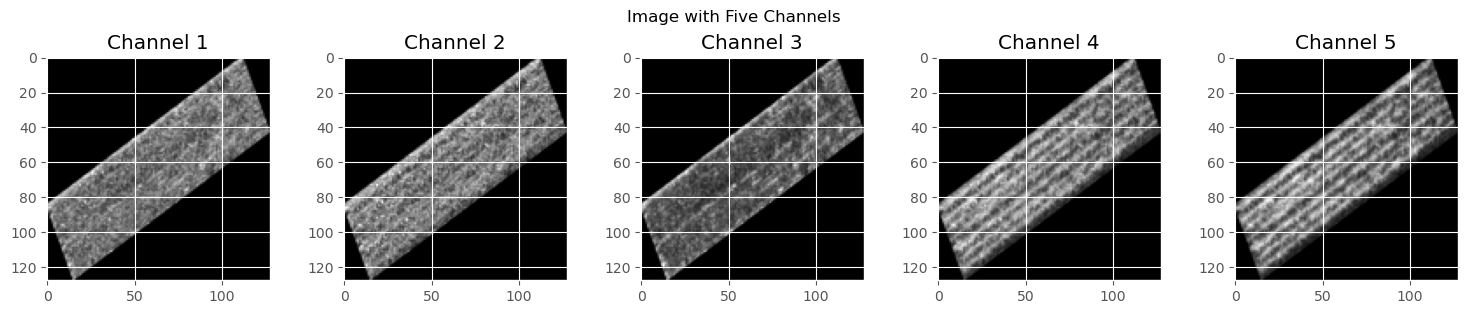

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming you have an image with shape (height, width, channels)
image = X[0].reshape(128, 128, 5)

# Create a figure and subplot for each channel
fig, axs = plt.subplots(nrows=1, ncols=5, figsize=(15, 3))

# Plot each channel separately
for i in range(5):
    channel = image[:, :, i]
    axs[i].imshow(channel, cmap='gray')
    axs[i].set_title(f'Channel {i+1}')

# Set the title of the figure
fig.suptitle('Image with Five Channels')

# Adjust the spacing between subplots
plt.tight_layout()

# Show the plot
plt.show()

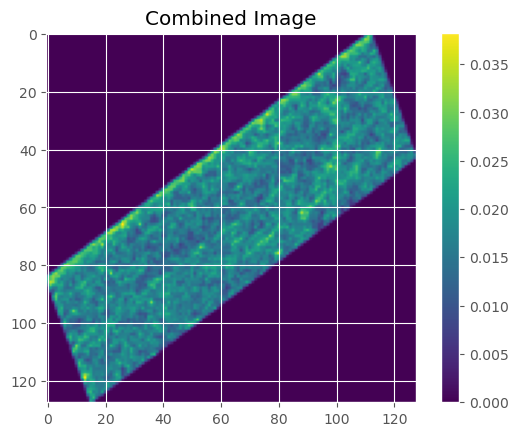

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming you have an image with shape (height, width, channels)
image = X[0].reshape(128, 128, 5)

# Choose three channels to combine
channel_indices = [0, 1, 2]  # Adjust the channel indices as desired

# Combine the chosen channels
combined_image = np.mean(image[:, :, channel_indices], axis=2)

# Plot the combined image
plt.imshow(combined_image)
plt.title('Combined Image')
plt.colorbar()

# Show the plot
plt.show()

In [12]:
pred = model.predict(X_test)

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'\nTest accuracy: {test_acc}')

4/4 [==============================] - 0s 31ms/step

Test accuracy: 0.8655462265014648


In [13]:
# Print how many labels exist in the dataset
print(df['Label'].value_counts())

Y_pred_classes = np.argmax(pred,axis = 1) 
Y_true = np.argmax(y_test,axis = 1)

Label
UNHEALTHY    486
HEALTHY      106
Name: count, dtype: int64


In [122]:
import numpy as np
import shap

# Assuming you have defined Y_pred_classes, Y_true, X_test, and pred earlier in your code

# Calculate SHAP values for the entire test set
#print(model)
#explainer = shap.DeepExplainer(model, (X_test[0:100]))
#print(X_test)
#shap_values = explainer.shap_values(X_test)

# Aggregate SHAP values across all samples
mean_shap_values_real = np.mean(np.abs(shap_values_real), axis=0)
mean_shap_values_synthetic = np.mean(np.abs(shap_values_synthetic), axis=0)

# Find the channel with the highest mean SHAP value
most_relevant_channel_real = np.argmax(np.mean(mean_shap_values_real, axis=(0, 1)))
most_relevant_channel_synthetic = np.argmax(np.mean(mean_shap_values_synthetic, axis=(0, 1)))

print("The most relevant channel is:", most_relevant_channel_real)
print("The most relevant channel is:", most_relevant_channel_synthetic)

Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
`tf.keras.backend.set_learning_phase` is deprecated and will be removed after 2020-10-11. To update it, simply pass a True/False value to the `training` argument of the `__call__` method of your layer or model.


The most relevant channel is: 2
The most relevant channel is: 6
